# Chapter 21 -- Cellular IoT Technologies: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** -- eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the figure and the printed
> numbers, then read the analysis before moving to the next exercise.
> Exercise 21.3 reuses the repetition/data-rate model built in Exercise 21.2,
> so the exercises are best run in sequence the first time through. Where
> stochastic simulation is used (Exercise 21.4), an explicit fixed seed is
> provided; Exercises 21.1-21.3 are deterministic given their input
> parameters.

---
## Setup

The cell below builds the shared toolkit used throughout this notebook. Every
numerical constant is drawn from a specific, cited source -- either a
published 3GPP-derived link-budget table, a peer-reviewed empirical
measurement paper, or an operator's own published documentation -- and is
commented with that source at the point of definition. Two points are worth
stating up front, because they shape how the rest of the notebook is worded:

1. **NB-IoT's network configures up to three Coverage Enhancement Levels
   (commonly labelled ECL0/1/2) via network-signalled RSRP thresholds, not
   via a fixed table of dB values.** The commonly cited 144/154/164 dB
   figures are representative reference planning points, not a universal
   normative one-to-one mapping. Exercise 21.1 treats the repetition factor
   needed to reach each reference point as a *model output* under an
   explicitly idealised combining assumption, not as a standardised value.
2. **Exercise 21.3's energy model uses real measured constants** (median
   Joules and microwatts) from a single peer-reviewed empirical measurement
   campaign on commercial NB-IoT hardware, rather than a set of blog-sourced
   currents combined into an ad-hoc averaged model.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import math

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.6,
})

# ─────────────────────────────────────────────────────────────────────────
# NB-IoT networks configure up to three Coverage Enhancement Levels (ECL)
# through network-signalled RSRP thresholds and associated resources.
# This exercise uses representative reference MCL planning points:
#   ECL0 (Normal)  -> 144 dB   (also the legacy GPRS reference target)
#   ECL1 (Robust)  -> 154 dB
#   ECL2 (Extreme) -> 164 dB
# (Michelinakis et al. 2021, Sec. II-B, citing 3GPP TR 45.820 / TS 36.331).
# These are not a universal normative one-to-one mapping of ECL to MCL.
# The operator configures repetition, MCS, and transmit power for its
# deployment; each ECL has no single universally fixed repetition count. In this exercise we
# instead ask a narrower, clearly-scoped question: assuming *idealised*
# coherent combining, how many uplink repetitions R would in principle be
# needed to close each of these three published targets, starting from the
# same 3GPP-published uplink link-budget table used to calibrate 164 dB
# (Ratilainen, IETF-97)? This R is a *model output*, not a normative
# repetition count.
ECL_TARGETS_DB = {'ECL0 (Normal)': 144.0, 'ECL1 (Robust)': 154.0, 'ECL2 (Extreme)': 164.0}

TX_POWER_DBM = 23.0             # NB-IoT UE power class 3
THERMAL_NOISE_DENSITY = -174.0  # dBm/Hz, kT at T = 290 K
NF_DB = 3.0                     # eNB receiver noise figure
BW_HZ = 15000.0                 # single-tone NPUSCH, one 15 kHz subcarrier

EFF_NOISE_DBM = THERMAL_NOISE_DENSITY + NF_DB + 10*np.log10(BW_HZ)   # -129.2 dBm

# Calibration anchor: published required SINR = -11.8 dB at the maximum
# uplink data-channel repetition R=128, reproducing the 164 dB ECL2 target
# (Ratilainen, IETF-97 LPWAN presentation).
R_MAX_NBIOT = 128
SINR_REQ_AT_RMAX = -11.8
SINR_REQ_R1 = SINR_REQ_AT_RMAX + 10*np.log10(R_MAX_NBIOT)


def nbiot_sensitivity_dbm(R):
    """NB-IoT NPUSCH receiver sensitivity (dBm) at uplink repetition factor
    R, under the idealised coherent-combining approximation
    SINR_req(R) = SINR_req(1) - 10 log10(R), calibrated to reproduce the
    published 164 dB MCL at R=128. This is a modelling simplification
    (see Design Note), not a claim about the true combining efficiency of
    a specific receiver implementation."""
    sinr_req = SINR_REQ_R1 - 10*np.log10(R)
    return EFF_NOISE_DBM + sinr_req


def nbiot_mcl_db(R):
    """NB-IoT maximum coupling loss (dB) at uplink repetition factor R,
    under the same idealised model."""
    return TX_POWER_DBM - nbiot_sensitivity_dbm(R)


def required_repetition_for_mcl(target_mcl_db):
    """Idealised repetition factor R needed to reach a target MCL, solving
    Equation (the calibrated model) for R. Not a normative value -- see
    Background."""
    sensitivity_needed = TX_POWER_DBM - target_mcl_db
    sinr_needed = sensitivity_needed - EFF_NOISE_DBM
    log2R = (SINR_REQ_R1 - sinr_needed) / (10*np.log10(2))
    return 2**log2R


# ─────────────────────────────────────────────────────────────────────────
# Macro-cell propagation model used only to translate the abstract MCL
# numbers into an order-of-magnitude coverage radius (Exercise 21.1). We
# reuse the Hata (Okumura-Hata) urban macro-cell formula -- the same
# general-purpose tool used in Chapter 20 -- to avoid re-deriving a
# separate propagation model, but note explicitly where it is being
# extrapolated beyond its original validity range.
#
# IMPORTANT VALIDITY CAVEAT: Hata's original formula was fitted to
# measurements over d = 1-20 km, f = 150-1500 MHz, base-station height
# 30-200 m, and mobile height 1-10 m (Hata, 1980). Several of the
# deep-indoor results below fall below the 1 km lower bound and must be
# read as order-of-magnitude extrapolations, not survey-grade predictions;
# this is flagged again at the point where such values are reported.
def hata_urban_900(d_km, hb_m=30.0, hm_m=1.5, f_mhz=900.0):
    a_hm = (1.1*np.log10(f_mhz) - 0.7)*hm_m - (1.56*np.log10(f_mhz) - 0.8)
    return (69.55 + 26.16*np.log10(f_mhz) - 13.82*np.log10(hb_m) - a_hm
            + (44.9 - 6.55*np.log10(hb_m))*np.log10(d_km))


PENETRATION_DB = {'outdoor': 0.0, 'light-indoor': 10.0, 'deep-indoor': 20.0}
SHADOW_SIGMA_DB = {'outdoor': 6.0, 'light-indoor': 8.0, 'deep-indoor': 10.0}


def coverage_probability(d_km, scenario, mcl_db):
    """Reuses, without re-deriving, the log-normal shadowing
    coverage-probability construction introduced in Chapter 20
    (Eq. 20.3)."""
    pl_mean = hata_urban_900(d_km) + PENETRATION_DB[scenario]
    z = (mcl_db - pl_mean) / SHADOW_SIGMA_DB[scenario]
    return norm.cdf(z)


def range_at_coverage(scenario, mcl_db, target_p=0.90, d_max_km=30, n=6000):
    d = np.linspace(0.05, d_max_km, n)
    p = coverage_probability(d, scenario, mcl_db)
    ok = d[p >= target_p]
    return ok[-1] if len(ok) else 0.0


# ─────────────────────────────────────────────────────────────────────────
# LTE-M (Cat-M1) reference points, used in Exercise 21.2 only. Baseline
# (no coverage enhancement) MCL is the Rel-12 LTE reference value 3GPP
# itself uses when quoting NB-IoT's "+20 dB over LTE" improvement
# (TR 36.888). The two coverage-mode figures are operator-published
# figures (Deutsche Telekom LTE-M network documentation) describing
# documented network capability at each coverage-enhancement mode; the
# source does not describe a dedicated field measurement campaign, so
# they are treated here as published implementation-level values, not as
# an independent experimental result.
LTE_BASELINE_MCL_DB = 142.7
LTEM_CE_MODE_A = {'R': 32, 'gain_db': 5.0}
LTEM_CE_MODE_B = {'R': 2048, 'gain_db': 15.0}
LTEM_OFFICIAL_TARGET_MCL_DB = 155.7

# ─────────────────────────────────────────────────────────────────────────
# Repetition -> effective data rate (Exercise 21.2). Calibrated to the one
# published NPUSCH single-tone data point: a layer-1 rate of ~20 bps at
# R=128 (Wang et al. 2017), under the simplified assumption that repeating
# the same transport block R times divides the effective rate by R. The
# resulting R=1 rate (2560 bps) is an internal, back-calculated reference
# point implied by this simplification -- it is not an independently
# published nominal NPUSCH data rate, and should not be read as one.
NPUSCH_DR_AT_RMAX_BPS = 20.0
NPUSCH_DR_BASE_BPS = NPUSCH_DR_AT_RMAX_BPS * R_MAX_NBIOT


def nbiot_datarate_bps(R):
    return NPUSCH_DR_BASE_BPS / R


T_OVERHEAD_S = 1.0
PAYLOAD_BITS = 64


def message_duration_s(R):
    return T_OVERHEAD_S + PAYLOAD_BITS / nbiot_datarate_bps(R)


# ─────────────────────────────────────────────────────────────────────────
# Exercise 21.3 energy model. Unlike the simplified constant-current model
# used in earlier drafts of this exercise, every constant below is a
# median value taken directly from a single published empirical
# measurement campaign on commercial NB-IoT hardware (Michelinakis et al.,
# IEEE Internet of Things Journal, 2021), which instruments real
# u-blox SARA-N211 and Quectel BC95 modules on two live commercial
# networks and reports energy consumption (in Joules) per named
# operational phase, rather than a single averaged current. We reuse
# their reported medians directly, together with their stated lifetime
# equation, rather than re-deriving currents from vendor blog posts.
BATTERY_CAPACITY_J = 18000.0   # 5 Wh reference cell (3GPP TR 45.820 target)

# Connected-state energy per uplink report (median, good coverage),
# Quectel BC95 module, Operator 2 -- Table IV of Michelinakis et al. (2021)
E_CONNECTED_DEFAULT_J = 0.82     # default timers (full inactivity-timer tail)
E_CONNECTED_RAI_J = 0.12         # RAI-400 (immediate release after ACK)

# Connected-state energy per report broken down by NB-IoT Coverage
# Enhancement Level, same module/operator, poor-coverage samples
# -- Table V of Michelinakis et al. (2021). These are REAL measured
# figures, not a repetition-based extrapolation, and are used directly
# to connect this exercise back to the coverage classes of Exercise 21.1.
E_CONNECTED_BY_ECL_J = {'ECL0 (Normal)': 0.88, 'ECL1 (Robust)': 1.03, 'ECL2 (Extreme)': 3.44}

# PSM deep-sleep power (median across both modules) -- Sec. VI-A of
# Michelinakis et al. (2021): 9.35-10.61 uW, consistent with the 2-5 uA
# range at ~3.6-3.7 V quoted elsewhere in the same source.
P_PSM_W = 10.0e-6

# eDRX listening-phase energy and duration (median, good coverage,
# Quectel BC95) -- Table VII of Michelinakis et al. (2021).
E_EDRX_LISTEN_J = 6.4e-3
T_EDRX_LISTEN_S = 0.215


def daily_energy_j(reports_per_day, e_connected_j, include_edrx=False,
                    edrx_cycles_per_day=0):
    """Total daily energy (J): connected-state reports + PSM sleep for the
    remainder of the day (+ optional eDRX listening cycles). Matches the
    lifetime equation of Michelinakis et al. (2021), Eq. (2)."""
    e_active = reports_per_day * e_connected_j
    e_edrx = edrx_cycles_per_day * E_EDRX_LISTEN_J if include_edrx else 0.0
    e_psm = P_PSM_W * 86400.0   # PSM for (approximately) the whole day
    return e_active + e_edrx + e_psm


def battery_life_years(reports_per_day, e_connected_j, **kwargs):
    e_day = daily_energy_j(reports_per_day, e_connected_j, **kwargs)
    return BATTERY_CAPACITY_J / e_day / 365.0


# ─────────────────────────────────────────────────────────────────────────
# NPRACH random-access model (Exercise 21.4). An NPRACH resource is
# configured with nprach-NumSubcarriers in {12, 24, 36, 48} subcarriers
# (3GPP TS 36.211, Sec. 10.1.6.1; Liu et al. 2021). In single-tone NPRACH
# with frequency hopping, a contending device selects one of these
# subcarriers uniformly at random as the starting frequency of its
# preamble, so the configured subcarrier count plays the role of the
# number of independent, simultaneously available random-access resources
# per NPRACH period -- referred to below as N for brevity. This exercise
# evaluates ONLY the resulting single-period collision probability; it
# does not model preamble repetition duration, coverage-class resource
# partitioning, retransmission/backoff, or scheduling of the subsequent
# data channels, and its output should not be read as a cell-capacity
# figure (see Design Note, Exercise 21.4).
def mc_random_access_success(N, M, trials=4000, rng=None):
    rng = rng if rng is not None else np.random.default_rng()
    successes = np.empty(trials)
    for t in range(trials):
        choices = rng.integers(0, N, size=M)
        counts = np.bincount(choices, minlength=N)
        successes[t] = np.sum(counts == 1)
    return successes.mean()


def analytic_expected_success(N, M):
    return M * (1 - 1/N)**(M - 1)


def per_attempt_success_probability(N, M):
    """Probability that a single, specific device's attempt is
    collision-free: the probability that none of the other M-1 devices
    chose the same subcarrier. This is a DIFFERENT quantity from
    normalised throughput (expected successes / N): the two coincide only
    at M = N (G = 1), and diverge at other offered loads -- see
    Exercise 21.4 for a worked comparison."""
    return (1 - 1/N)**(M - 1)


print("Environment ready.")


Environment ready.


---
## Exercise 21.1 -- Coupling-Loss Budget and Coverage-Enhancement Levels

### Background

Chapter 20 planned LoRaWAN coverage by fitting an empirical path-loss curve
to distance and asking how far a fixed transmit power carries before it
falls below a fixed receiver sensitivity. Cellular network planners answer a
narrower but far more standardised question first, using a different tool:
the **maximum coupling loss (MCL)**, the largest loss a link can tolerate --
between transmitter and receiver antenna ports, antenna gains excluded --
while the service still closes. NB-IoT's network configures up to three
**Coverage Enhancement Levels (ECL)** via network-signalled RSRP
thresholds and associated random-access resource parameters, commonly
labelled ECL0 (Normal), ECL1 (Robust), and ECL2 (Extreme). For this
exercise, MCL values of 144, 154, and 164 dB are used as **representative
reference planning points** commonly associated with progressively
enhanced NB-IoT coverage conditions [Michelinakis et al., 2021, Sec.
II-B] -- 144 dB also being the target associated with legacy GPRS. They
are **not** a universal normative one-to-one mapping of the standardised
CE levels, whose actual selection is controlled through
network-configured RSRP thresholds rather than a single fixed table of dB
values. A base station assigns a device to one of these levels from its
measured received power; the operator separately configures which
repetition count, MCS, and transmit power actually close each reference
link budget in its own deployment. There is **no single universal
repetition count** attached to "ECL1" or "ECL2" in the standard itself,
and the 164 dB figure specifically is still usefully referred to as
NB-IoT's headline maximum coupling-loss design target.

This exercise asks a narrower, explicitly-scoped question instead: starting
from the same published 3GPP-derived uplink link-budget table used
throughout this chapter [Ratilainen, IETF-97], and assuming *idealised*
coherent combining (the same simplification examined critically in Exercise
21.2), how many repetitions would in principle be needed to close each of
the three representative reference planning points? The resulting
repetition factor is a **model output**, useful for connecting the
"144/154/164 dB" reference points to the repetition mechanism explored
later in this chapter -- not a claim about a standardised or universally
observed repetition count.

The approximately 20 dB improvement NB-IoT's 164 dB target represents
*over the legacy GPRS link budget* (144 dB) is explicitly described in the
standardisation and vendor literature as being of the same order as the
additional loss introduced by penetrating a single exterior building wall
-- a statement about the *improvement*, not about the full 164 dB budget
itself. That framing motivates the second half of this exercise: rather
than varying a urban/suburban/rural macro-environment as Chapter 20 did,
we hold the macro-environment fixed and vary **building-penetration loss**
(outdoor / light-indoor / deep-indoor), reusing -- without re-deriving --
the log-normal shadowing coverage-probability construction introduced in
Chapter 20 (Eq. 20.3).

> **A note on precision.** The Hata (Okumura-Hata) propagation model used
> below to convert MCL into distance was originally fitted to measurements
> over 1-20 km, 150-1500 MHz, with base-station heights of 30-200 m [Hata,
> 1980]. Several of the deep-indoor results in this exercise fall below the
> 1 km lower bound of that range and are therefore **order-of-magnitude
> extrapolations**, not survey-grade predictions. They are reported to one
> decimal place, rather than three significant figures, for exactly this
> reason, and the figure below marks the 1 km boundary explicitly.

In [2]:
# ── Exercise 21.1: coupling-loss budget for the three ECL targets ──────
print("Idealised repetition factor needed to reach each published ECL target:")
print(f"{'Coverage class':<16s} {'Target MCL (dB)':>16s} {'Idealised R':>12s}")
for name, mcl in ECL_TARGETS_DB.items():
    R = required_repetition_for_mcl(mcl)
    print(f"{name:<16s} {mcl:16.1f} {R:12.2f}")

print()
print("Nearest standard (power-of-two) repetition levels: R = 1, ~16, 128")
print("(ECL1's idealised value of ~13 falls between the standard levels")
print("R=8 and R=16; the network would in practice round up to R=16 to")
print("guarantee the target margin is met.)")


Idealised repetition factor needed to reach each published ECL target:
Coverage class    Target MCL (dB)  Idealised R
ECL0 (Normal)               144.0         1.27
ECL1 (Robust)               154.0        12.69
ECL2 (Extreme)              164.0       126.85

Nearest standard (power-of-two) repetition levels: R = 1, ~16, 128
(ECL1's idealised value of ~13 falls between the standard levels
R=8 and R=16; the network would in practice round up to R=16 to
guarantee the target margin is met.)


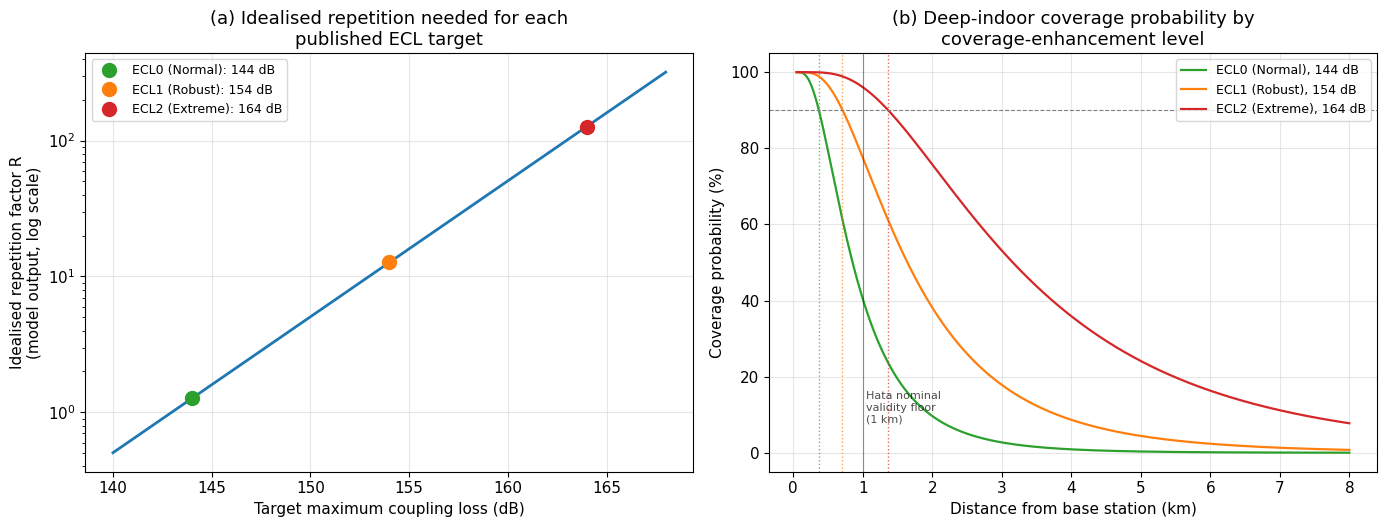

Saved fig_21_1_linkbudget.png


In [3]:
# ── Figure 21.1: idealised repetition vs ECL target, and coverage prob ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

# (a) idealised R needed vs target MCL (NB-IoT only in this figure --
# the LTE-M idealised-vs-real combining discussion is deferred to
# Exercise 21.2, where it is the main subject rather than a side note)
ax = axes[0]
mcl_fine = np.linspace(140, 168, 200)
R_fine = np.array([required_repetition_for_mcl(m) for m in mcl_fine])
ax.semilogy(mcl_fine, R_fine, '-', color='tab:blue', lw=2)
colors_ecl = {'ECL0 (Normal)': 'tab:green', 'ECL1 (Robust)': 'tab:orange',
              'ECL2 (Extreme)': 'tab:red'}
for name, mcl in ECL_TARGETS_DB.items():
    R = required_repetition_for_mcl(mcl)
    ax.plot(mcl, R, 'o', color=colors_ecl[name], ms=10, label=f'{name}: {mcl:.0f} dB')
ax.set_xlabel('Target maximum coupling loss (dB)')
ax.set_ylabel('Idealised repetition factor R\n(model output, log scale)')
ax.set_title('(a) Idealised repetition needed for each\npublished ECL target')
ax.legend(fontsize=9)

# (b) Coverage probability vs distance, deep-indoor scenario, 3 ECL levels
ax = axes[1]
d = np.linspace(0.05, 8, 500)
for name, mcl in ECL_TARGETS_DB.items():
    p = coverage_probability(d, 'deep-indoor', mcl)
    ax.plot(d, p*100, color=colors_ecl[name], label=f'{name}, {mcl:.0f} dB')
    r90 = range_at_coverage('deep-indoor', mcl)
    ax.axvline(r90, color=colors_ecl[name], ls=':', lw=1.0, alpha=0.7)

ax.axhline(90, color='gray', ls='--', lw=0.8)
ax.axvline(1.0, color='black', ls='-', lw=0.8, alpha=0.4)
ax.text(1.05, 8, 'Hata nominal\nvalidity floor\n(1 km)', fontsize=8, alpha=0.7)
ax.set_xlabel('Distance from base station (km)')
ax.set_ylabel('Coverage probability (%)')
ax.set_title('(b) Deep-indoor coverage probability by\ncoverage-enhancement level')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('fig_21_1_linkbudget.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_21_1_linkbudget.png")


In [4]:
# ── Exercise 21.1 output: 90%-coverage range by ECL and scenario ───────
print(f"{'Coverage class':<16s} {'MCL(dB)':>8s} {'outdoor(km)':>12s} "
      f"{'light-indoor(km)':>17s} {'deep-indoor(km)':>16s}")
for name, mcl in ECL_TARGETS_DB.items():
    r_out = range_at_coverage('outdoor', mcl)
    r_light = range_at_coverage('light-indoor', mcl)
    r_deep = range_at_coverage('deep-indoor', mcl)
    # Values below 1 km fall outside Hata's nominal validity range and are
    # rounded to one decimal place only, to avoid implying survey-grade
    # precision for what is here an extrapolation (see Background).
    fmt = lambda r: f"{r:.1f}" if r < 1.0 else f"{r:.2f}"
    print(f"{name:<16s} {mcl:8.1f} {fmt(r_out):>12s} {fmt(r_light):>17s} {fmt(r_deep):>16s}")


Coverage class    MCL(dB)  outdoor(km)  light-indoor(km)  deep-indoor(km)
ECL0 (Normal)       144.0         1.91               0.8              0.4
ECL1 (Robust)       154.0         3.67              1.61              0.7
ECL2 (Extreme)      164.0         7.06              3.11             1.36


### Analysis

The first result is a useful consistency check on the model, not a proof of
anything about how these reference points came to be commonly cited:
solving the idealised model backwards for the repetition factor needed to
close each reference planning point gives
R &asymp; 1.3 for the 144 dB point, R &asymp; 12.7 for the 154 dB point, and R
&asymp; 126.9 for the 164 dB point -- all close to the "clean" values (1, ~16,
128) a reader familiar with NB-IoT's standardised repetition levels would
expect. That agreement is consistent with the idealised combining
approximation being a reasonable first-order description of how the 164 dB
figure was arrived at; it is not, on its own, independent proof of that
origin, since the same qualitative pattern (larger MCL needs more
repetition) would appear under almost any monotonic combining-gain model.

**Figure 21.1(a)** shows this model output as a continuous curve, with the
three reference points marked. **Figure 21.1(b)** and **Table 21.1**
translate the three reference planning points into 90%-coverage radii
under three building-penetration scenarios. The pattern is qualitatively
consistent with the "one building wall" framing: at ECL0, deep-indoor
coverage is a small
fraction of the outdoor range at the same level, and climbing to ECL2
roughly triples to quadruples it. Because several of the deep-indoor and
light-indoor figures fall below Hata's nominal 1 km validity floor (marked
explicitly in the figure), these specific numbers should be read as directional
and order-of-magnitude, not as a substitute for a site-specific outdoor-to-indoor
propagation study.

<div style="background:#eef6ff;border-left:4px solid #4477aa;padding:8px 14px;margin:12px 0;">
<b>Key takeaway.</b> NB-IoT's Coverage Enhancement Levels are selected through
network-configured RSRP thresholds; 144/154/164 dB are representative
reference planning points, not a universal normative mapping. Operators
configure repetition, MCS, and power for their own deployment. An idealised
combining model can connect these reference points to an illustrative
repetition factor and, from there, to a
coverage radius, but every step involves a named simplification (idealised
combining; a propagation model reused outside part of its original validity
range) that should be stated alongside the resulting number, not implied
away by it.
</div>

**Challenge tasks.**
1. The model uses a fixed eNodeB noise figure of 3 dB. Repeat the analysis
   for 5 dB and quantify how the idealised repetition factor for each ECL
   target changes.
2. Recompute Table 21.1 using a genuine outdoor-to-indoor propagation model
   (e.g., ITU-R P.1411 or a 3GPP TR 38.901-style indoor-loss model) instead
   of Hata-plus-fixed-penetration, and compare the resulting deep-indoor
   ranges to the ones reported here.
3. Recompute Table 21.1 for a suburban macro-cell (larger base-station
   height, lower shadowing standard deviation) and discuss which
   penetration scenario benefits most from the change in environment.
4. The idealised repetition value for ECL1 (&asymp;12.7) does not land on a
   standard power-of-two repetition level. Discuss, from a network-operator
   perspective, why rounding up to R=16 (rather than down to R=8) is the
   conservative choice, and what it costs in the data-rate terms quantified
   in Exercise 21.2.

---
## Exercise 21.2 -- Repetition, Data Rate, and the Idealised-vs-Published Combining Gap

### Background

Repetition is one of the principal mechanisms NB-IoT uses to extend
coverage, alongside its narrow channel bandwidth, robust low-rate coding,
and low-order modulation: rather than hearing a weak signal more loudly,
the receiver hears it *more times* and combines the repetitions. The
idealised version of that idea is coherent combining: repeating a signal R times and
summing the received copies improves the effective SINR by
10 log<sub>10</sub> R decibels -- the same formula used in Exercise 21.1 to
connect NB-IoT's reference MCL planning points to a repetition factor. That
consistency check is worth revisiting critically here, because repetition
is not free: sending the same transport block R times takes R times as
long, so the *effective* data rate falls in direct proportion, and so does
the latency budget for a fixed payload.

This exercise quantifies that cost side precisely, and then asks a sharper
question: how much of the *idealised* 10 log<sub>10</sub> R combining gain
is actually reflected in a deployed technology's own documented figures?
LTE-M (Cat-M1) offers a useful comparison point here, because at least one
European operator's own network documentation states a coverage gain of
**up to 5 dB with CE Mode A** (32 repetitions), a mode that documentation
identifies as supported on its own deployed network, and separately
documents **up to 15 dB with CE Mode B** (2048 repetitions) as a standard
LTE-M capability, without stating that CE Mode B is itself enabled on that
specific network [Deutsche Telekom / IoT Creators documentation]. We
therefore treat the CE Mode A figure as an operator-documented figure for
a deployed network, and the CE Mode B figure as an operator-documented
figure for the standard capability more broadly -- both are useful
comparison points against the idealised bound below, but neither should be
read as an independent field-measurement campaign, and we avoid drawing a
precise causal conclusion from a two-point comparison, since
coverage-enhancement gain in a real network depends on channel conditions,
coding, scheduling, and receiver implementation choices that are not
reducible to a single number.

> **Model parameters.** NPUSCH single-tone (15 kHz) data rate calibrated to
> the one published reference value of &asymp;20 bps at maximum repetition
> (R=128) [Wang et al., 2017] &middot; inverse-linear rate model
> DR(R) = DR(1)/R (a stated simplification -- see Design Note) &middot;
> 8-byte application payload &middot; 1 s fixed random-access/RRC connection
> overhead (design assumption) &middot; LTE-M repetition range
> R &isin; {1, 32, 2048} (no CE / CE Mode A / CE Mode B).

In [5]:
# ── Exercise 21.2: repetition, data rate, and message duration ─────────
Rs = [1, 2, 4, 8, 16, 32, 64, 128]
print(f"{'R':>4s} {'DR (bps)':>10s} {'T_active (s)':>13s} {'Ideal gain (dB)':>16s}")
for R in Rs:
    dr = nbiot_datarate_bps(R)
    ta = message_duration_s(R)
    ideal_gain = 10*np.log10(R)
    print(f"{R:4d} {dr:10.2f} {ta:13.3f} {ideal_gain:16.2f}")

print("\nLTE-M idealised combining bound vs. operator-published gain:")
for R, published in [(LTEM_CE_MODE_A['R'], LTEM_CE_MODE_A['gain_db']),
                     (LTEM_CE_MODE_B['R'], LTEM_CE_MODE_B['gain_db'])]:
    ideal = 10*np.log10(R)
    print(f"  R={R:5d}: idealised bound = {ideal:5.1f} dB   "
          f"operator-published gain = {published:4.1f} dB   "
          f"ratio to idealised bound = {published/ideal*100:4.1f}%")


   R   DR (bps)  T_active (s)  Ideal gain (dB)
   1    2560.00         1.025             0.00
   2    1280.00         1.050             3.01
   4     640.00         1.100             6.02
   8     320.00         1.200             9.03
  16     160.00         1.400            12.04
  32      80.00         1.800            15.05
  64      40.00         2.600            18.06
 128      20.00         4.200            21.07

LTE-M idealised combining bound vs. operator-published gain:
  R=   32: idealised bound =  15.1 dB   operator-published gain =  5.0 dB   ratio to idealised bound = 33.2%
  R= 2048: idealised bound =  33.1 dB   operator-published gain = 15.0 dB   ratio to idealised bound = 45.3%


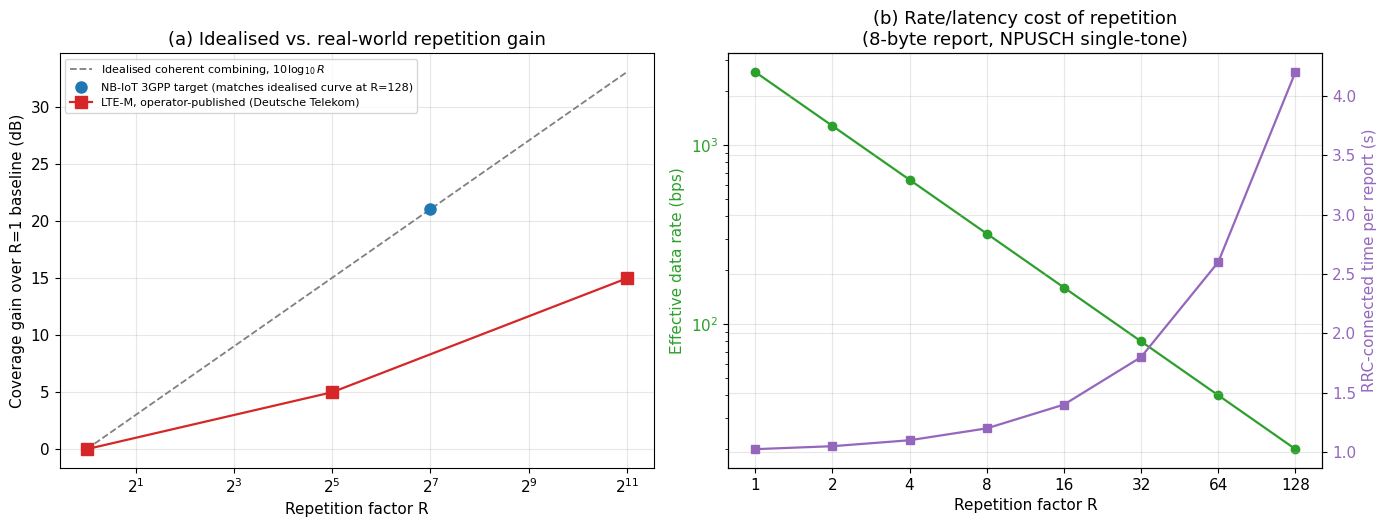

Saved fig_21_2_repetition_tradeoff.png


In [6]:
# ── Figure 21.2: idealised vs. real combining gain; rate/latency trade-off ─
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

# (a) idealised vs. operator-documented coverage gain
ax = axes[0]
R_range = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048])
ideal_gain = 10*np.log10(R_range)
ax.plot(R_range, ideal_gain, '--', color='gray', lw=1.3,
        label='Idealised coherent combining, $10\\log_{10}R$')
ax.plot([1, R_MAX_NBIOT], [0, 10*np.log10(R_MAX_NBIOT)], 'o', color='tab:blue',
        ms=8, label='NB-IoT 3GPP target (matches idealised curve at R=128)')
ax.plot([1, LTEM_CE_MODE_A['R'], LTEM_CE_MODE_B['R']],
        [0, LTEM_CE_MODE_A['gain_db'], LTEM_CE_MODE_B['gain_db']],
        's-', color='tab:red', ms=8, label='LTE-M, operator-published (Deutsche Telekom)')
ax.set_xscale('log', base=2)
ax.set_xlabel('Repetition factor R')
ax.set_ylabel('Coverage gain over R=1 baseline (dB)')
ax.set_title('(a) Idealised vs. real-world repetition gain')
ax.legend(fontsize=8, loc='upper left')

# (b) data rate and message duration vs R
ax = axes[1]
Rs_arr = np.array([1, 2, 4, 8, 16, 32, 64, 128])
dr = np.array([nbiot_datarate_bps(R) for R in Rs_arr])
ta = np.array([message_duration_s(R) for R in Rs_arr])
ax.semilogy(Rs_arr, dr, 'o-', color='tab:green', label='Effective data rate (bps)')
ax.set_xscale('log', base=2)
ax.set_xticks(Rs_arr); ax.set_xticklabels(Rs_arr)
ax.set_xlabel('Repetition factor R')
ax.set_ylabel('Effective data rate (bps)', color='tab:green')
ax.tick_params(axis='y', labelcolor='tab:green')

ax2 = ax.twinx()
ax2.plot(Rs_arr, ta, 's-', color='tab:purple', label='Message duration (s)')
ax2.set_ylabel('RRC-connected time per report (s)', color='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:purple')
ax.set_title('(b) Rate/latency cost of repetition\n(8-byte report, NPUSCH single-tone)')

plt.tight_layout()
plt.savefig('fig_21_2_repetition_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_21_2_repetition_tradeoff.png")


### Analysis

**Figure 21.2(a)** puts the idealised combining curve side by side with
LTE-M's operator-documented points, and the gap is substantial. At R=32 (CE
Mode A), the idealised formula predicts a 15.1 dB gain, but Deutsche
Telekom's own documentation for this, deployed, mode states a gain of only
5 dB -- an absolute shortfall of about 10.1 dB. At R=2048 (CE Mode B), the
idealised prediction is 33.1 dB against a documented 15 dB, a shortfall of
about 18.1 dB. We report this gap in decibels rather than as a percentage:
because decibels are a logarithmic quantity, the ratio of two dB figures
does not correspond to a percentage of realised linear gain, and
converting it to one would itself be a modelling error. Two data points,
drawn moreover from a deployed mode (A) and a documented-but-not-necessarily-
deployed mode (B), cannot isolate which mechanism (non-coherent combining
losses, channel-estimation degradation over long repetition sequences,
frequency-hopping overhead, or implementation margin) accounts for most of
this gap, but the direction and rough magnitude are clear: the documented
figures for this operator's network fall well short of the idealised
combining bound at both coverage modes.

This is worth reading back against Exercise 21.1's consistency check.
There, the calibration point (R=128 &rarr; 164 dB) was used to derive the
model; the remaining reference planning points (144 and 154 dB) were shown
to be *consistent with* that calibrated first-order model, which is a
weaker and more accurate claim than saying they are independently
reproduced by it. LTE-M's own documented coverage-mode figures, by
contrast, are not consistent with the same idealised formula -- they sit
well below it at both CE modes. This does not mean NB-IoT's 164 dB design
target is inflated -- 3GPP conformance testing validates it under
controlled conditions that are, by construction, closer to the idealised
assumptions than an arbitrary live deployment. It does mean that a
standardised *target*, a *calibrated
model output*, and a *documented network capability figure* are three
different kinds of number, and that comparing them side by side -- rather
than treating any one alone as "the"
answer -- is the more defensible way to reason about coverage claims in
this space.

**Figure 21.2(b)** quantifies the cost side. Message duration for an 8-byte
report grows from about 1.0 s at R=1 to about 4.2 s at R=128, while the
underlying data rate collapses by a full factor of 128, from an implied
2560 bps down to the one published anchor point of 20 bps. That collapse is
what makes coverage enhancement expensive in Exercise 21.3: every extra
repetition a device needs to close the link is extra time its radio must
stay active, which is extra battery drained on every report it ever sends.

<div style="background:#fff4e6;border-left:4px solid #cc7a00;padding:8px 14px;margin:12px 0;">
<b>Design note.</b> The inverse-linear rate model DR(R)=DR(1)/R is a
simplification calibrated to a single published data point (20 bps at
R=128); the resulting R=1 rate of 2560 bps is an internal, back-calculated
reference point implied by this simplification, not an independently
published nominal NPUSCH data rate, and should not be quoted as one. A
production capacity study should instead use the standardised NPUSCH
transport-block-size and resource-unit tables (3GPP TS 36.213).
</div>

<div style="background:#eef6ff;border-left:4px solid #4477aa;padding:8px 14px;margin:12px 0;">
<b>Key takeaway.</b> Repetition trades data rate for coupling loss at
roughly 10 log<sub>10</sub> R dB under an idealised combining assumption,
but LTE-M's own operator-documented coverage-mode figures sit well below
that bound at both of its coverage-enhancement modes. Reading a
standards-derived target and a vendor- or operator-documented capability
figure side by side, rather than substituting one for the other, is the
more defensible way to reason about coverage claims for cellular IoT
technologies.
</div>

**Challenge tasks.**
1. Repeat the effective-data-rate calculation for a 200-byte payload (the
   3GPP 10-year battery-life reference payload) instead of 8 bytes. At what
   repetition factor does the message duration first exceed the 10-second
   uplink report latency target quoted in the NB-IoT design goals?
2. Look up the exact NPUSCH single-tone transport-block-size table for one
   modulation and coding scheme (3GPP TS 36.213) and compute the *true*
   data rate at R=1 and R=128, comparing it directly to the inverse-linear
   model's implied baseline of 2560 bps.
3. Using only the two Deutsche Telekom data points, fit a power law
   gain(R) = a&middot;R<sup>b</sup> and compare the fitted exponent b to the
   idealised value implicit in 10 log<sub>10</sub> R. Discuss why fitting
   any curve to only two points is a weak basis for extrapolation.
4. Find one additional published or peer-reviewed source reporting an
   achieved (not idealised) LTE-M or NB-IoT coverage gain at a stated
   repetition factor, and add it to Figure 21.2(a). Does it fall closer to
   the idealised bound or to the Deutsche Telekom points?

---
## Exercise 21.3 -- Battery Life from Published NB-IoT Energy Measurements

### Background

NB-IoT's other headline design target, alongside its coverage targets, is
**ten years of battery life on a 5 Wh cell**, assuming a device reports
around 200 bytes per day [3GPP TR 45.820]. Reaching anywhere near that
figure depends on how a device manages three very different energy states:
**Power Saving Mode (PSM)**, a deep-sleep state in which the radio is
switched off but the device *remains registered with the network and
retains its context* -- it does **not** detach, but it is unreachable for
mobile-terminated traffic until it next wakes; **extended Discontinuous
Reception (eDRX)**, in which the device periodically wakes for a short
"listening" window to check for paging before returning to sleep; and the
**Connected state**, comprising synchronisation, the actual uplink/downlink
transmission, and -- critically -- an **inactivity-timer tail** during
which the device continues monitoring the downlink control channel after
its last transmission, before the connection is finally released.

Earlier drafts of this exercise combined these into a single, flat,
averaged "idle current," which understates exactly the mechanism most
responsible for real-world energy waste: the connected-state inactivity
timer. This exercise instead uses **published, per-phase median energy
figures from a single peer-reviewed empirical measurement campaign** on
commercial NB-IoT hardware (u-blox SARA-N211 and Quectel BC95 modules, two
live commercial operators) [Michelinakis et al., IEEE Internet of Things
Journal, 2021], which instruments real devices and reports Joules per named
phase rather than a single averaged current. Their central finding is
directly relevant here: **most of the energy per report is consumed during
the Connected-state inactivity-timer tail, not during the actual data
transfer** -- and a 3GPP feature called the **Release Assistance Indicator
(RAI)**, which lets a device tell the network it has no further data
coming and skip that tail, can reduce total per-report energy by an order
of magnitude.

> **Model parameters.** Reference battery: 18 000 J (5 Wh, the 3GPP
> reference cell) &middot; Connected-state energy per report (Quectel BC95,
> good coverage, median): 0.82 J with default timers, 0.12 J with RAI-400
> &middot; PSM power (median, both modules): &asymp;10 &micro;W &middot;
> Connected-state energy by measured Coverage Enhancement Level (poor
> coverage, default timers): ECL0 0.88 J, ECL1 1.03 J, ECL2 3.44 J. All
> values above are taken directly from Michelinakis et al. (2021).

In [7]:
# ── Exercise 21.3: battery life from published NB-IoT energy measurements ─
print(f"Reference battery: {BATTERY_CAPACITY_J:.0f} J (5 Wh, the 3GPP NB-IoT reference cell)\n")

print("Lifetime vs. reporting interval (Quectel BC95 module, good coverage,")
print("median measured energy per report -- Michelinakis et al. 2021):")
print(f"{'Interval':>10s} {'Reports/day':>12s} {'Default (yr)':>13s} {'RAI-400 (yr)':>13s}")
for hours in [1, 4, 24]:
    rpd = 24 / hours
    life_default = battery_life_years(rpd, E_CONNECTED_DEFAULT_J)
    life_rai = battery_life_years(rpd, E_CONNECTED_RAI_J)
    print(f"{hours:>8d}h {rpd:12.1f} {life_default:13.2f} {life_rai:13.2f}")

print("\n(Michelinakis et al. report lifetimes of the same broad order across")
print("this range -- single digits to several tens of years -- from their own,")
print("more detailed per-operator dataset; our estimate uses their published")
print("median constants directly but omits periodic TAU energy and other")
print("second-order effects their full measurement captures, so it should be")
print("read as an independent, order-of-magnitude-consistent estimate rather")
print("than a reproduction of their exact figures.)")


Reference battery: 18000 J (5 Wh, the 3GPP NB-IoT reference cell)

Lifetime vs. reporting interval (Quectel BC95 module, good coverage,
median measured energy per report -- Michelinakis et al. 2021):
  Interval  Reports/day  Default (yr)  RAI-400 (yr)
       1h         24.0          2.40         13.17
       4h          6.0          8.53         31.13
      24h          1.0         29.28         50.12

(Michelinakis et al. report lifetimes of the same broad order across
this range -- single digits to several tens of years -- from their own,
more detailed per-operator dataset; our estimate uses their published
median constants directly but omits periodic TAU energy and other
second-order effects their full measurement captures, so it should be
read as an independent, order-of-magnitude-consistent estimate rather
than a reproduction of their exact figures.)


In [8]:
# ── Exercise 21.3 output: lifetime by measured coverage-enhancement level ─
print("Connected-state energy per report and battery life by ECL")
print("(real measured values, poor-coverage samples, default timers,")
print(" Quectel BC95 -- Table V of Michelinakis et al. 2021):\n")
print(f"{'Coverage class':<16s} {'E_connected (J)':>16s} {'Hourly (yr)':>12s} {'Daily (yr)':>11s}")
for name, e_j in E_CONNECTED_BY_ECL_J.items():
    life_hourly = battery_life_years(24, e_j)
    life_daily = battery_life_years(1, e_j)
    print(f"{name:<16s} {e_j:16.2f} {life_hourly:12.2f} {life_daily:11.2f}")


Connected-state energy per report and battery life by ECL
(real measured values, poor-coverage samples, default timers,
 Quectel BC95 -- Table V of Michelinakis et al. 2021):

Coverage class    E_connected (J)  Hourly (yr)  Daily (yr)
ECL0 (Normal)                0.88         2.24       28.28
ECL1 (Robust)                1.03         1.93       26.04
ECL2 (Extreme)               3.44         0.59       11.46


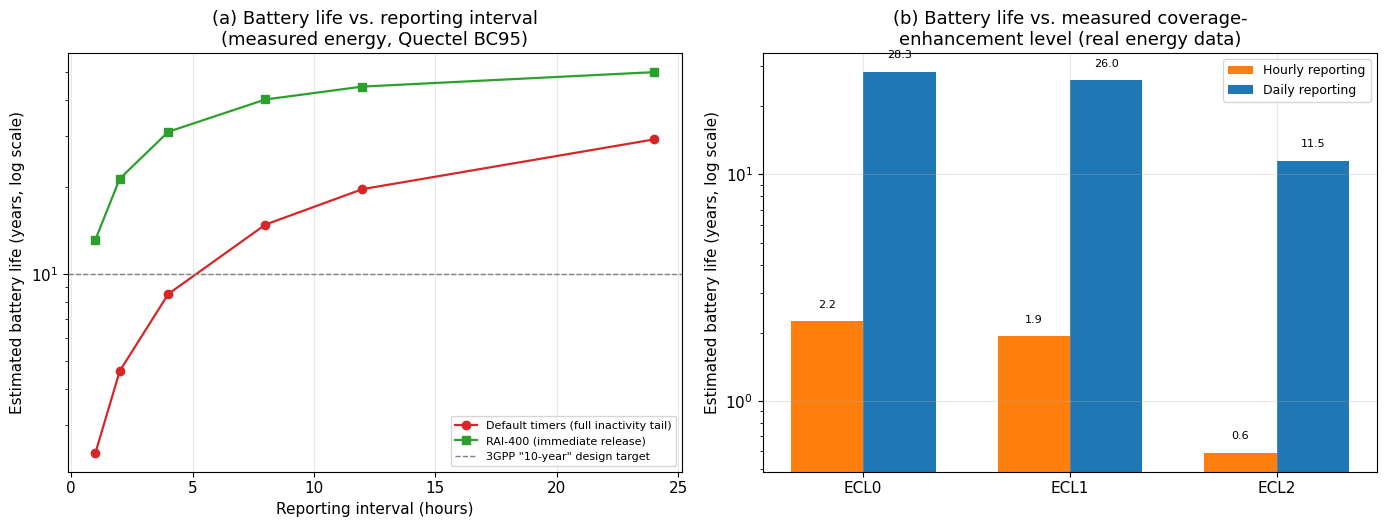

Saved fig_21_3_energy_battery.png


In [9]:
# ── Figure 21.3: measured battery life vs. interval, RAI, and ECL ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

# (a) lifetime vs reporting interval, default vs RAI-400
ax = axes[0]
hours_range = np.array([1, 2, 4, 8, 12, 24])
rpd_range = 24 / hours_range
life_default = [battery_life_years(r, E_CONNECTED_DEFAULT_J) for r in rpd_range]
life_rai = [battery_life_years(r, E_CONNECTED_RAI_J) for r in rpd_range]
ax.semilogy(hours_range, life_default, 'o-', color='tab:red', label='Default timers (full inactivity tail)')
ax.semilogy(hours_range, life_rai, 's-', color='tab:green', label='RAI-400 (immediate release)')
ax.axhline(10, color='gray', ls='--', lw=1.0, label='3GPP "10-year" design target')
ax.set_xlabel('Reporting interval (hours)')
ax.set_ylabel('Estimated battery life (years, log scale)')
ax.set_title('(a) Battery life vs. reporting interval\n(measured energy, Quectel BC95)')
ax.legend(fontsize=8)

# (b) lifetime vs measured ECL-dependent energy
ax = axes[1]
names = list(E_CONNECTED_BY_ECL_J.keys())
e_vals = list(E_CONNECTED_BY_ECL_J.values())
x = np.arange(len(names))
width = 0.35
life_h = [battery_life_years(24, e) for e in e_vals]
life_d = [battery_life_years(1, e) for e in e_vals]
ax.bar(x - width/2, life_h, width, label='Hourly reporting', color='tab:orange')
ax.bar(x + width/2, life_d, width, label='Daily reporting', color='tab:blue')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([n.split(' (')[0] for n in names])
ax.set_ylabel('Estimated battery life (years, log scale)')
ax.set_title('(b) Battery life vs. measured coverage-\nenhancement level (real energy data)')
ax.legend(fontsize=9)
for i, v in enumerate(life_h):
    ax.text(i - width/2, v*1.15, f"{v:.1f}", ha='center', fontsize=8)
for i, v in enumerate(life_d):
    ax.text(i + width/2, v*1.15, f"{v:.1f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_21_3_energy_battery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_21_3_energy_battery.png")


### Analysis

**Figure 21.3(a)** shows the effect of the inactivity-timer tail directly.
At an hourly reporting interval, using default timers gives an estimated
lifetime of about 2.4 years; enabling RAI-400 (immediate release after the
downlink acknowledgement) raises that to roughly 13 years, using the
source paper's representative medians for the same module and operator --
the RAI-400 figure is specifically reported for a 20-byte packet, whereas
the default-timer figure aggregates the corresponding good-coverage
measurement set, so the two are not literally identical aggregates in
every respect, but the dominant configuration change the two published
values represent is whether the device continues monitoring the downlink
after each report. This matches the qualitative finding of the source
measurement campaign: the inactivity-timer tail, not the payload
transmission itself, dominates per-report energy under default settings,
and a single configuration choice (the RAI flag) is often the single
largest lever available to an application developer, larger in this data
than the payload-size effects explored in Exercise 21.2.

**Figure 21.3(b)** connects this back to the coverage classes of Exercise
21.1, but now with **real measured energy** rather than a repetition-based
extrapolation: the same Quectel BC95 module, under default timers, consumes
0.88 J per report at ECL0, 1.03 J at ECL1, and 3.44 J at ECL2 -- roughly a
4&times; increase in per-report energy between the best and worst measured
coverage classes. At hourly reporting this pulls estimated battery life
down from about 2.2 years (ECL0) to about 0.6 years (ECL2); at a sparser
daily reporting cadence the same ECL range moves from about 28 years down
to about 11 years. The direction of this result is consistent with Exercise
21.1 and 21.2's repetition-based story (deeper coverage costs more energy
per report), but the magnitude here comes from direct measurement, not from
extrapolating a repetition formula.

<div style="background:#eef6ff;border-left:4px solid #4477aa;padding:8px 14px;margin:12px 0;">
<b>Key takeaway.</b> Power Saving Mode does not mean the device leaves the
network -- it remains registered but becomes temporarily unreachable for
mobile-terminated traffic while it is in PSM (a period that can last hours
or days, not necessarily briefly). The
single largest, best-documented lever over real NB-IoT battery life in this
measurement campaign is not the coverage class or the payload size, but
whether the connected-state inactivity timer is allowed to run its course
or is cut short via RAI. A "10-year battery life" claim is only as
meaningful as the reporting cadence, coverage class, <i>and</i> RAI
configuration it assumes -- all four numbers are needed together, not any
one of them alone.
</div>

<div style="background:#fff4e6;border-left:4px solid #cc7a00;padding:8px 14px;margin:12px 0;">
<b>Design note -- what this estimate omits.</b> Our lifetime estimate uses
the source paper's published median constants and its stated lifetime
equation, but --- unlike the source's own, more detailed dataset --- it
omits periodic Tracking Area Update (TAU) energy and assumes the device
spends effectively the entire non-transmitting period in PSM. It is
therefore an independent, order-of-magnitude-consistent estimate built from
the same published constants, not a reproduction of the source paper's own
reported lifetime table, which may differ from the figures above as a
result of these and other second-order effects captured directly in their
measurements but not in this simplified model. Furthermore, the
multi-decade figures above (up to 50.1 years at a 24-hour interval with
RAI) are **idealised communication-energy upper bounds**, not realistic
service-life predictions: they account only for the radio energy this
model tracks, and exclude battery self-discharge, calendar ageing,
temperature effects, voltage-regulator losses, sensor and microcontroller
consumption, leakage currents, and any practical product-lifetime limit.
Read them as evidence that, at sufficiently sparse reporting, radio energy
stops being the dominant constraint on device lifetime -- not as a claim
that a real product would run for 50 years.
</div>

**Challenge tasks.**
1. Read Section II-A of Michelinakis et al. (2021) on the eDRX listening
   phase and extend the model to include periodic eDRX wake-ups (using the
   published median listening energy and duration) for a use case that
   requires downlink reachability, rather than assuming eDRX is disabled.
2. The model here omits periodic TAU energy. Using the extended-T3412
   timer range in 3GPP TS 24.301 (on the order of 413 days at its
   theoretical maximum, though individual operators typically configure a
   much shorter value), estimate how much periodic TAU energy could
   *reduce* the lifetime estimates above.
3. Reproduce the ECL-based comparison (Figure 21.3(b)) using the
   u-blox SARA-N211 module's own measured values instead of Quectel BC95's
   (both are reported in the source paper), and discuss how much the choice
   of module changes the conclusion.
4. Using the RAI-400 energy figure and the measured ECL2 (poor-coverage)
   energy figure together, estimate the combined benefit of enabling RAI
   *and* being in good coverage, versus each factor considered alone.

---
## Exercise 21.4 -- NPRACH Random-Access Collision Probability

### Background

NB-IoT is designed to support a very large population of devices per cell,
and every device must first announce itself to the network before it can be
scheduled, using the **Narrowband Physical Random Access Channel
(NPRACH)**. An NPRACH resource is configured with a number of subcarriers,
`nprach-NumSubcarriers` &isin; {12, 24, 36, 48} [3GPP TS 36.211, Sec.
10.1.6.1; Liu et al., 2021]. NB-IoT's NPRACH preamble is transmitted
single-tone with frequency hopping: a contending device selects one of
these subcarriers uniformly at random as the starting frequency of its
preamble, so the configured subcarrier count effectively sets the number of
independent, simultaneously available random-access resources per period,
which we call N below. If two devices independently choose the same
subcarrier in the same period, the base station cannot in general
distinguish them, and both attempts fail.

This is a textbook "balls into bins" problem, mathematically identical to
the birthday-paradox family of collision problems and to the classical
analysis of slotted-ALOHA random-access channels. This exercise validates
the closed-form collision model with direct Monte Carlo simulation, and
distinguishes two related but different quantities that are easy to
conflate: the **normalised throughput** $S/N = \mathbb{E}[\text{successes}]/N$
(the fraction of the $N$ available subcarriers that end up carrying a
successful attempt -- a network-side, resource-utilisation view), and the
**per-attempt success probability** $P_{\text{success}} = (1-1/N)^{M-1}$
(the probability that one specific device's own attempt succeeds -- a
device-side view). The two coincide only when $M=N$ (i.e.\ $G=1$); at any
other offered load they diverge, sometimes substantially, and a result
phrased in one without saying which is easy to misread as the other.

> **What this exercise deliberately does not compute.** It is tempting to
> multiply a peak per-period success count by periods-per-hour and call the
> result a "device capacity" or "cell capacity" figure. We avoid that step
> here. A widely cited 3GPP-derived planning figure of approximately 52 547
> devices per cell sector [3GPP TR 45.820] is a *system-level*
> target that accounts for the full traffic model, scheduling of the
> subsequent data channels, retransmission and backoff, and the coexistence
> of multiple coverage classes -- none of which this single-collision-model
> exercise represents. The rate computed below should be read only as an
> illustrative NPRACH-feasibility number, not as a validation or
> reproduction of that system-level figure.

> **Model parameters.** N=48 subcarriers (the maximum configurable value;
> this exercise assumes all 48 are available as contention-based starting
> subcarriers -- see Design Note) &middot; offered load
> G = M/N &isin; [0.05, 4] &middot; 800-4000 Monte Carlo trials per point
> &middot; no retransmission, backoff, or capture effect modelled
> &middot; representative NPRACH periodicities of 80 ms, 640 ms, and
> 2560 ms.

In [10]:
# ── Exercise 21.4: NPRACH random-access collision probability ──────────
rng = np.random.default_rng(2024)
N_SUBCARRIERS = 48  # nprach-NumSubcarriers, maximum configurable value
# NOTE: this exercise assumes all 48 configured subcarriers are available
# as contention-based starting subcarriers (see Design Note) -- in a real
# deployment nprach-NumCBRA-StartSubcarriers may reserve part of this
# range for non-contention access, and the range may be further shared
# across multiple coverage-enhancement groups.

# Two DIFFERENT quantities are computed below and must not be conflated:
#   (1) Normalised throughput S/N = E[successes]/N -- the fraction of the
#       N available subcarriers that end up carrying a successful attempt.
#       This is the network-side resource-utilisation view.
#   (2) Per-attempt success probability P_success = (1-1/N)^(M-1) -- the
#       probability that any ONE specific device's attempt succeeds. This
#       is the device-side view.
# The two are numerically equal only when M = N (i.e. G = 1); at any
# other offered load they diverge, sometimes substantially.
G_values = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0]
print(f"{'Load G=M/N':>10s} {'M devices':>10s} {'MC success':>11s} "
      f"{'Analytic':>9s} {'Norm. thruput S/N':>19s} {'P(success), 1 device':>21s}")
for G in G_values:
    M = int(round(G * N_SUBCARRIERS))
    sim = mc_random_access_success(N_SUBCARRIERS, M, trials=3000, rng=rng)
    ana = analytic_expected_success(N_SUBCARRIERS, M)
    p_success = per_attempt_success_probability(N_SUBCARRIERS, M)
    print(f"{G:10.2f} {M:10d} {sim:11.2f} {ana:9.2f} "
          f"{ana/N_SUBCARRIERS*100:18.1f}% {p_success*100:20.1f}%")

print("\nNote how far apart these two columns are at low load (G=0.25):")
print("normalised throughput ~20%, but a lightly-loaded individual device")
print("still succeeds ~79% of the time -- the two views only coincide at")
print("G=1 (M=N), where every subcarrier is, on average, claimed by")
print("exactly one device.")

# Exact finite-N discrete maximum of M*(1-1/N)^(M-1): for integer M, this
# is attained at BOTH M=N-1 and M=N (the ratio of successive terms equals
# exactly 1 at M=N, a general property of this function), not uniquely at
# M=N. We report the M=N=48 value below; M=47 gives the identical result.
exact_peak_throughput = analytic_expected_success(N_SUBCARRIERS, N_SUBCARRIERS) / N_SUBCARRIERS
exact_peak_at_47 = analytic_expected_success(N_SUBCARRIERS, N_SUBCARRIERS - 1) / N_SUBCARRIERS
print(f"\nExact finite-N discrete maximum throughput at N={N_SUBCARRIERS}:")
print(f"  at M={N_SUBCARRIERS}:   {exact_peak_throughput*100:.2f}%")
print(f"  at M={N_SUBCARRIERS-1}:   {exact_peak_at_47*100:.2f}%  (identical, as expected)")
print(f"Classical asymptotic slotted-ALOHA limit (N -> infinity): "
      f"1/e = {100/np.e:.2f}%")
print("As N grows, this discrete optimum approaches the classical")
print("continuous-load point G=1, with throughput approaching 1/e; the")
print("exact finite-N value above, not the asymptotic limit, is used in")
print("the rate estimate below.")

# What this exercise does NOT compute: a cell-capacity or device-density
# figure. It computes only the single-NPRACH-period NORMALISED THROUGHPUT
# for a chosen number of contending devices. Converting this into a
# sustainable *rate* of successful access attempts requires an assumed
# NPRACH periodicity, which we make explicit below -- and even that rate
# is not a device count, since it says nothing about repetition duration,
# coverage-class resource partitioning, retransmissions, or the capacity
# of the data channels a successful access attempt is followed by.
print("\nIllustrative successful-access-attempt rate at peak load (G=1),")
print("for three representative NPRACH periodicities:")
periodicities = {'Short (80 ms)': 0.08, 'Medium (640 ms)': 0.64, 'Long (2560 ms)': 2.56}
attempt_rates = {}
for label, period_s in periodicities.items():
    periods_per_hour = 3600 / period_s
    rate = exact_peak_throughput * N_SUBCARRIERS * periods_per_hour
    attempt_rates[label] = rate
    print(f"  {label:18s}: ~{rate:>10,.0f} successful access attempts/hour "
          f"(NOT a device count -- see Design Note)")


Load G=M/N  M devices  MC success  Analytic   Norm. thruput S/N  P(success), 1 device
      0.25         12        9.59      9.52               19.8%                 79.3%
      0.50         24       14.82     14.79               30.8%                 61.6%
      1.00         48       17.75     17.84               37.2%                 37.2%
      1.50         72       16.15     16.15               33.6%                 22.4%
      2.00         96       13.04     12.99               27.1%                 13.5%


      3.00        144        7.09      7.09               14.8%                  4.9%

Note how far apart these two columns are at low load (G=0.25):
normalised throughput ~20%, but a lightly-loaded individual device
still succeeds ~79% of the time -- the two views only coincide at
G=1 (M=N), where every subcarrier is, on average, claimed by
exactly one device.

Exact finite-N discrete maximum throughput at N=48:
  at M=48:   37.18%
  at M=47:   37.18%  (identical, as expected)
Classical asymptotic slotted-ALOHA limit (N -> infinity): 1/e = 36.79%
As N grows, this discrete optimum approaches the classical
continuous-load point G=1, with throughput approaching 1/e; the
exact finite-N value above, not the asymptotic limit, is used in
the rate estimate below.

Illustrative successful-access-attempt rate at peak load (G=1),
for three representative NPRACH periodicities:
  Short (80 ms)     : ~   802,999 successful access attempts/hour (NOT a device count -- see Design Note)
  Medium (640 m

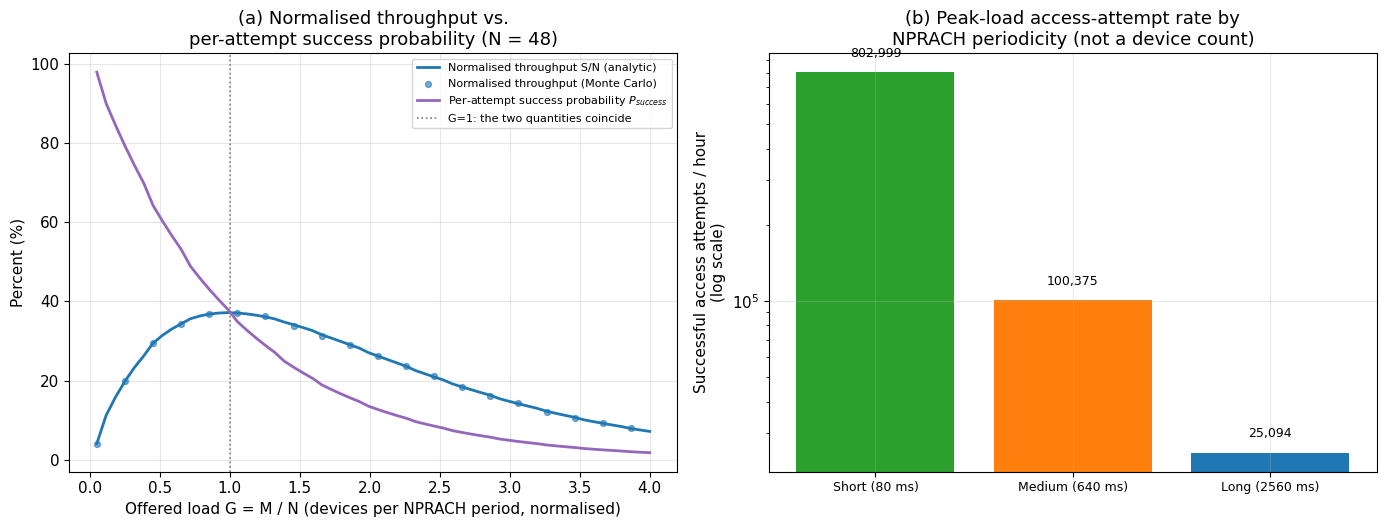

Saved fig_21_4_random_access.png


In [11]:
# ── Figure 21.4: throughput vs. per-attempt success probability, and rate ─
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

# (a) two DIFFERENT quantities vs. offered load: normalised throughput
# (network-side resource utilisation) and per-attempt success probability
# (device-side view). They coincide only at G=1.
ax = axes[0]
G_plot = np.linspace(0.05, 4, 60)
M_plot = np.round(G_plot * N_SUBCARRIERS).astype(int)
sim_throughput = np.array([mc_random_access_success(N_SUBCARRIERS, m, trials=800, rng=rng)
                            for m in M_plot]) / N_SUBCARRIERS
ana_throughput = np.array([analytic_expected_success(N_SUBCARRIERS, m)
                            for m in M_plot]) / N_SUBCARRIERS
ana_p_success = np.array([per_attempt_success_probability(N_SUBCARRIERS, m)
                           for m in M_plot])

ax.plot(G_plot, ana_throughput*100, '-', color='tab:blue', lw=2,
        label='Normalised throughput S/N (analytic)')
ax.scatter(G_plot[::3], sim_throughput[::3]*100, color='tab:blue', s=18,
           zorder=5, alpha=0.6, label='Normalised throughput (Monte Carlo)')
ax.plot(G_plot, ana_p_success*100, '-', color='tab:purple', lw=2,
        label='Per-attempt success probability $P_{success}$')
ax.axvline(1.0, color='gray', ls=':', lw=1.2,
           label='G=1: the two quantities coincide')
ax.set_xlabel('Offered load G = M / N (devices per NPRACH period, normalised)')
ax.set_ylabel('Percent (%)')
ax.set_title('(a) Normalised throughput vs.\nper-attempt success probability (N = 48)')
ax.legend(fontsize=8)

# (b) successful-access-attempt rate at peak load, by NPRACH periodicity
# (explicitly NOT a device-density / cell-capacity figure -- see text)
ax = axes[1]
labels = list(attempt_rates.keys())
values = list(attempt_rates.values())
bars = ax.bar(range(len(labels)), values, color=['tab:green', 'tab:orange', 'tab:blue'])
ax.set_yscale('log')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Successful access attempts / hour\n(log scale)')
ax.set_title('(b) Peak-load access-attempt rate by\nNPRACH periodicity (not a device count)')
for i, v in enumerate(values):
    ax.text(i, v*1.15, f"{v:,.0f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_21_4_random_access.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_21_4_random_access.png")


### Analysis

**Figure 21.4(a)** shows just how far apart the two quantities can be.
At a light offered load (G=0.25), normalised throughput is only about
20% -- most of the 48 subcarriers go unused in any given period -- yet a
single lightly-loaded device succeeds on its own attempt about 79% of the
time, since it faces little competition. As load climbs toward G=1, both
curves converge and cross at exactly 37.2% (this exercise's exact,
finite-N=48 value, close to but numerically distinct from the classical
asymptotic $1/e\approx36.8\%$ slotted-ALOHA limit an infinite-resource
system would approach). Push load past G=1, and the two diverge again in
the opposite direction: normalised throughput falls only gradually, while
an individual device's own success probability collapses much faster,
because it is now competing against a growing crowd. Reporting only one
of these two numbers, without saying which, would tell a very different
and potentially misleading story depending on which stakeholder is asking
the question -- a network planner cares about throughput; a single
device's design engineer cares about its own success probability.

**Figure 21.4(b)** turns that single number into an illustrative
attempt-rate estimate: at peak load, a short 80 ms NPRACH period could in
principle support on the order of 8&times;10<sup>5</sup> successful access
attempts per hour, falling to roughly 10<sup>5</sup> at a 640 ms period and
roughly 2.5&times;10<sup>4</sup> at a 2560 ms period. These numbers fall on
either side of the widely cited $\sim$52,500-devices-per-cell planning
figure, which is a superficially appealing coincidence -- but, as stated in
the Background, that figure comes from a full system-level study this
exercise does not reproduce, and the "coincidence" should not be read as
validation.

<div style="background:#fff4e6;border-left:4px solid #cc7a00;padding:8px 14px;margin:12px 0;">
<b>Design note -- what this model excludes.</b> This is a single-period
collision-probability model. It excludes: retransmission and backoff after
a failed attempt; the "capture effect" (a base station can sometimes still
decode the stronger of two colliding signals); the duration of repeated
preamble transmissions at higher coverage classes; coexistence and resource
partitioning between multiple coverage groups sharing the 48 available
subcarriers; and the scheduling and capacity of the data channels a
successful random-access attempt is followed by. Any of these would change
the resulting attempt-rate estimate, most of them by narrowing it.
</div>

<div style="background:#eef6ff;border-left:4px solid #4477aa;padding:8px 14px;margin:12px 0;">
<b>Key takeaway.</b> Normalised throughput and per-attempt success
probability are two different, easy-to-conflate views of the same
collision model, and a NPRACH capacity claim needs to say which one it
means. Coverage enhancement constrains the random-access side of the
device-density budget specifically through NPRACH resource
configuration: longer, more heavily repeated NPRACH periods at deeper
coverage classes reduce how frequently access opportunities recur. This
is a real and quantifiable link between coverage and access capacity, but
it is one contributing factor among several, not a claim that repetition
is the single mechanism behind NB-IoT's overall device-density story.
</div>

**Challenge tasks.**
1. Add a simple retransmission model: a device that collides waits a random
   backoff and retries, up to 3 attempts. How much does this improve the
   *effective* success probability at G=1.5, and at what cost in average
   access delay?
2. Implement a simple capture-effect model (e.g., the stronger of two
   colliding signals succeeds if its power exceeds the weaker one by a
   threshold such as 6 dB) and quantify how much it raises the effective
   throughput ceiling above this exercise's exact finite-N collision-only
   limit of 37.2%.
3. Read Liu et al. (2021) and identify at least two mechanisms their
   full model includes that this exercise's single-period model omits.
   Which one do you expect has the largest effect on a realistic capacity
   estimate?
4. Using the coverage-class ranges from Exercise 21.1 (Table 21.1),
   estimate what fraction of a cell's geographic area falls into each
   coverage class for a chosen penetration scenario, and discuss
   qualitatively (without computing a device count) how this would change
   the demand placed on each coverage class's NPRACH resources.

---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|-------------------|
| 21.1 | Coupling-loss (MCL) budget, connected to three representative reference planning points | Distinguishes a headline coverage design target from representative reference points and a modelled repetition factor, and converts both into concrete coverage radii with explicit validity caveats |
| 21.2 | Repetition/combining-gain model, idealised bound vs. operator-documented figures | Quantifies the rate/latency cost of repetition and the absolute gap (in dB) between an idealised combining bound and a technology's own documented coverage-mode figures |
| 21.3 | Multi-phase energy accounting using published, peer-reviewed empirical measurements | Realistic, RAI- and coverage-class-dependent battery-life estimates built entirely from measured (not assumed) energy figures |
| 21.4 | Monte Carlo validation of NPRACH single-period collision probability | Explains how offered load and NPRACH resource configuration affect single-period collision throughput, without extending that into an unsupported capacity claim |

The four exercises are not four views of one single mechanism solving
every design goal; they are four carefully scoped angles on a family of
interacting trade-offs. Exercise 21.1 asked what coupling loss repetition
buys against NB-IoT's representative coverage reference points; Exercise 21.2 asked what
that same repetition costs in data rate, against both an idealised bound
and documented real-world figures; Exercise 21.3 asked what battery life
actually depends on, and found configuration choices (RAI) mattering at
least as much as the coverage-related repetition cost itself; and
Exercise 21.4 asked a narrower question again about random-access
throughput, deliberately stopping short of a capacity claim the model
cannot support. The recurring discipline across all four is the same one
applied throughout this book: state the model's assumptions explicitly,
distinguish a standard's target from a measured outcome, and stop the
analysis at the point the evidence actually supports. The following
sections of this chapter turn to the application scenarios where these
trade-offs are made in
practice.